# TerraMind Inference and Visualization
Load trained model, make predictions on Sen1Floods11 samples, and visualize results with RGB composites and ground truth overlay.

## 1. Import Required Libraries

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import logging
import argparse
import json
from pathlib import Path
from typing import Dict, Any, Tuple
import warnings
warnings.filterwarnings('ignore')

from terratorch.tasks import SemanticSegmentationTask
from terratorch import BACKBONE_REGISTRY
from terratorch.datamodules import GenericNonGeoSegmentationDataModule
from terratorch.datamodules.sen1floods11 import Sen1Floods11NonGeoDataModule

from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import TensorBoardLogger

import cv2
import albumentations as A


from terra_sat_drift.data_simulation.phisat2_constants import S2_BANDS_NAMES, S2_BANDS, S2_PAN_BANDS


# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

: 

In [28]:
root_dir=Path("/shared/home/elucas/datasets/sen1floods11_simulated")

# Load band statistics from JSON file
stats_file = f"{root_dir}/v1.1/spectral_statistics.json"
with open(stats_file, 'r') as f:
    stats = json.load(f)
    
dataset_bands = [0, 1, 2, 3, 4, 5, 6, 7]
# Don't use the PAN band for testing
output_bands = [0, 1, 2, 4, 5, 6, 7]

# Extract means and stds for all bands
means = list([stats[f"band_{i+1}"]["mean"] for i in output_bands])
stds = list([stats[f"band_{i+1}"]["std"] for i in output_bands])

TARGET_SIZE = (512, 512)

def preprocess_mask(mask, **kwargs):
    clean_mask = np.full(mask.shape, -1, dtype=np.int64)
    clean_mask[mask == 0] = 0
    clean_mask[mask == 1] = 1
    return clean_mask

transform = [
    A.Resize(width=TARGET_SIZE[0], height=TARGET_SIZE[1], interpolation=cv2.INTER_NEAREST),
    A.Lambda(mask=preprocess_mask),
    A.pytorch.ToTensorV2(),
]


simulated_datamodule = GenericNonGeoSegmentationDataModule(
    batch_size=8,
    data_root=root_dir,
    
    # We use the same roots for train/val/test and select samples via the given split files
    train_data_root=root_dir / "v1.1/data/flood_events/HandLabeled/S2Hand",
    train_label_data_root=Path("/shared/home/elucas/datasets/sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand"),
    val_data_root=root_dir / "v1.1/data/flood_events/HandLabeled/S2Hand",
    val_label_data_root=Path("/shared/home/elucas/datasets/sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand"),
    test_data_root=root_dir / "v1.1/data/flood_events/HandLabeled/S2Hand",
    test_label_data_root=Path("/shared/home/elucas/datasets/sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand"),

    # Split files
    train_split=root_dir / "v1.1/splits/flood_handlabeled/flood_train_data.txt",
    val_split=root_dir / "v1.1/splits/flood_handlabeled/flood_valid_data.txt",
    test_split=root_dir / "v1.1/splits/flood_handlabeled/flood_test_data.txt",
    
    train_transform=transform,
    val_transform=transform,
    test_transform=transform,
    means=means,
    stds=stds,
    dataset_bands=dataset_bands,
    output_bands=output_bands,
    num_workers=4,
    download=False,
    use_metadata=True,
    rgb_indices=[2, 1, 0],
    num_classes=2,
)

In [ ]:
simulated_datamodule.setup(stage="validate")
val_dataset = simulated_datamodule.val_dataset

print(f"Available samples in the validation set: {len(val_dataset)}")
print(f"Input shape of first sample: {val_dataset[0]['image'].shape}")
# print label shape
print(f"Label shape of first sample: {val_dataset[0]['mask'].shape}")

Available samples in the validation set: 89
Input shape of first sample: torch.Size([7, 512, 512])
Label shape of first sample: torch.Size([512, 512])


: 

In [17]:
root_dir="/shared/home/elucas/datasets/sen1floods11"

clean_datamodule = Sen1Floods11NonGeoDataModule(
    batch_size=8,
    data_root=root_dir,
    bands=S2_BANDS_NAMES,
    num_workers=4,
    download=False,
    use_metadata=True,
    rgb_indices=[3, 2, 1],
    num_classes=2,
)

In [18]:
clean_datamodule.setup(stage="validate")
val_dataset = clean_datamodule.val_dataset

print(f"Available samples in the training dataset: {len(val_dataset)}")
print(f"Input shape of first sample: {val_dataset[0]['image'].shape}")

Available samples in the training dataset: 89
Input shape of first sample: torch.Size([7, 512, 512])


In [19]:
trainer = Trainer(
    max_epochs=50,
    log_every_n_steps=10,
    enable_progress_bar=True,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [ ]:
task_clean = SemanticSegmentationTask.load_from_checkpoint(checkpoint_path="/shared/home/elucas/terra-sat-drift/outputs/terramind_sen1floods/terramind_v1_tiny/checkpoints/best-val_mIoU.ckpt")

trainer.test(model=task_clean, dataloaders=simulated_datamodule)

2026-05-13 09:29:55,915 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-tiny/resolve/main/TerraMind_v1_tiny.pt "HTTP/1.1 302 Found"
2026-05-13 09:29:55,917 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
2026-05-13 09:30:00,716 - INFO - Checking stackability for test split.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃          Test metric           ┃          DataLoader 0          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/Accuracy          │       0.7344551086425781       │
│       test/Boundary_mIoU       │      0.05712185800075531       │
│ test/Class_Accuracy_background │       0.8805595636367798       │
│   test/Class_Accuracy_flood    │       0.5883506536483765       │
│         test/F1_Score          │       0.6976701021194458       │
│      test/IoU_background       │       0.8310190439224243       │
│         test/IoU_flood         │       0.3224261701107025       │
│      test/Pixel_Accuracy       │       0.8435954451560974       │
│           test/loss            │       0.5915019512176514       │
│           test/mIoU            │       0.5767226219177246       │
│        test/mIoU_Micro         │       0.7294986248016357       │
└────────────────────────────────┴────────────────────────────────┘

[{'test/loss': 0.5915019512176514,
  'test/Accuracy': 0.7344551086425781,
  'test/Boundary_mIoU': 0.05712185800075531,
  'test/Class_Accuracy_background': 0.8805595636367798,
  'test/Class_Accuracy_flood': 0.5883506536483765,
  'test/F1_Score': 0.6976701021194458,
  'test/IoU_background': 0.8310190439224243,
  'test/IoU_flood': 0.3224261701107025,
  'test/Pixel_Accuracy': 0.8435954451560974,
  'test/mIoU': 0.5767226219177246,
  'test/mIoU_Micro': 0.7294986248016357}]

## 3. Prepare Sample Data and Create RGB Composites

In [21]:
task_clean.eval()

simulated_datamodule.setup("test")

test_loader = simulated_datamodule.test_dataloader()
test_dataset = simulated_datamodule.test_dataset
print(f"Available samples in the test dataset: {len(test_dataset)}")

2026-05-13 09:36:44,158 - INFO - Checking stackability for test split.


Available samples in the test dataset: 89


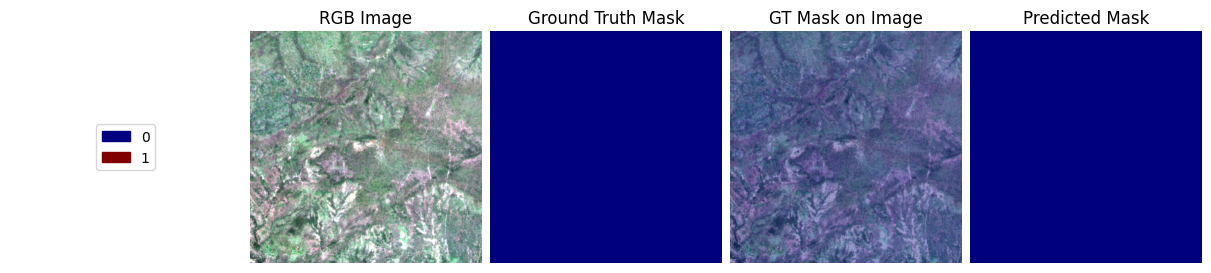

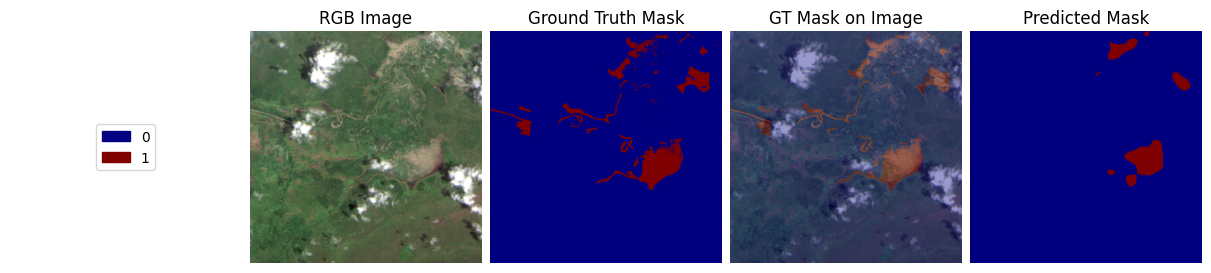

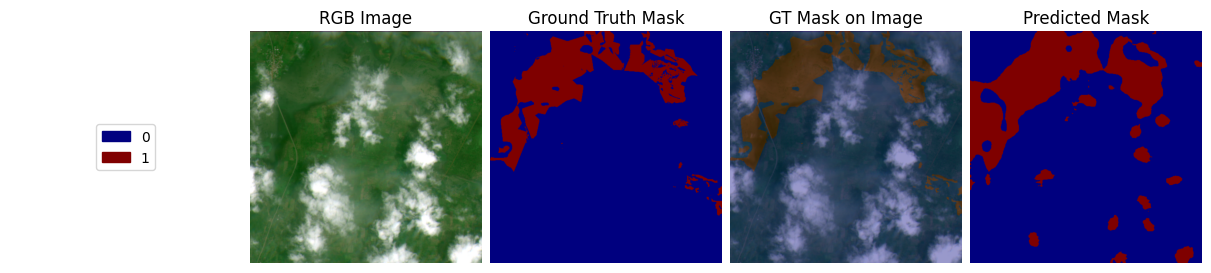

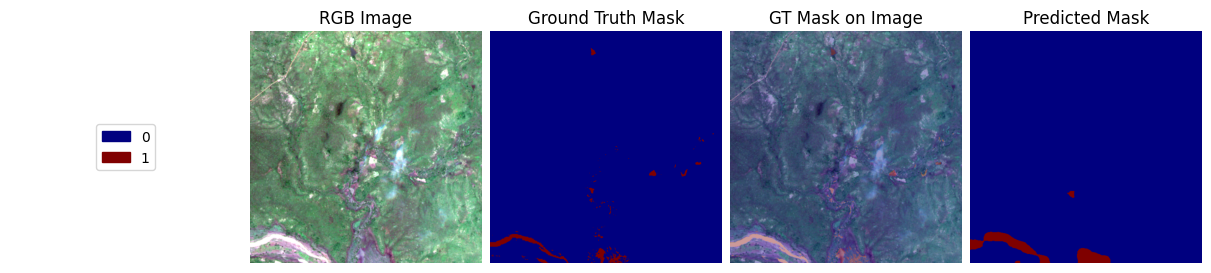

In [23]:
with torch.no_grad():
    batch = next(iter(test_loader))
    # Apply the same normalization used during training
    batch = simulated_datamodule.aug(batch)
    images = batch["image"].to(task_clean.device)
    masks = batch["mask"].cpu().numpy()

    outputs = task_clean(images)
    preds = torch.argmax(outputs.output, dim=1).cpu().numpy()

# Visualize a few predictions
num_examples = min(6, len(preds))
for i in range(2, num_examples):
    sample = {
        "image": batch["image"][i].cpu(),
        "mask": batch["mask"][i].squeeze().cpu(),
        "prediction": preds[i],
    }
    test_dataset.plot(sample)